In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

for dirname, _, filenames in os.walk("./"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

The goal is to understand which customers are most likely to make a purchase of a select item. By looking at basic customer details like age, gender, and estimated salary, we aim to build a system that can predict whether a person is likely to buy the item or not.

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Project_3.csv')
print("Shape:", df.shape)
print("\n")

print("1. FIRST 5 ROWS:")
print(df.head())
print("\n")

Shape: (1001, 6)


1. FIRST 5 ROWS:
   User ID                 name  Gender  Age  EstimatedSalary  Purchased
0    10000  Mr. Charles Carroll  Female   59            90627          0
1    10001         Timothy Wood    Male   37            91731          1
2    10002       Danny Whitaker    Male   46           137970          1
3    10003       Franklin Villa    Male   27           108371          0
4    10004        Carrie Miller  Female   23           118024          1




# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

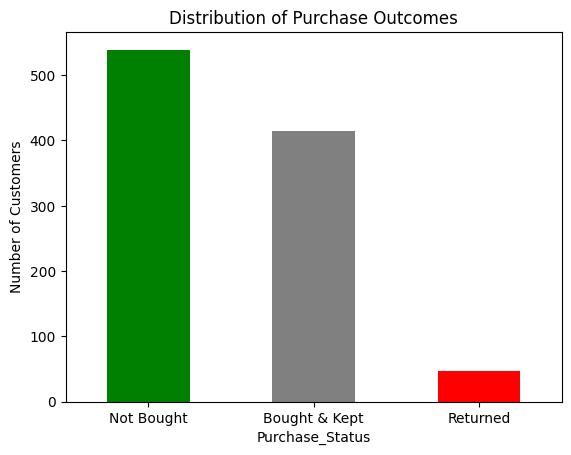

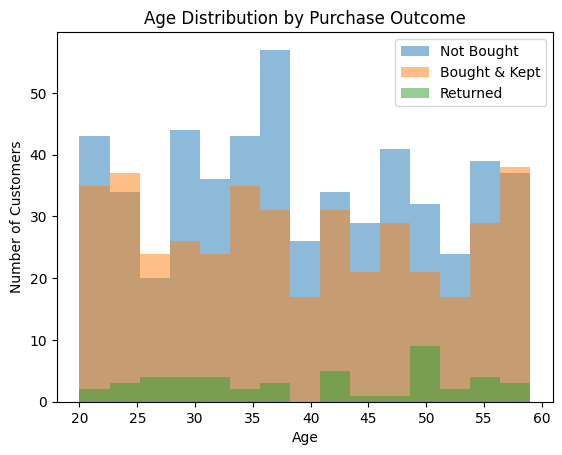

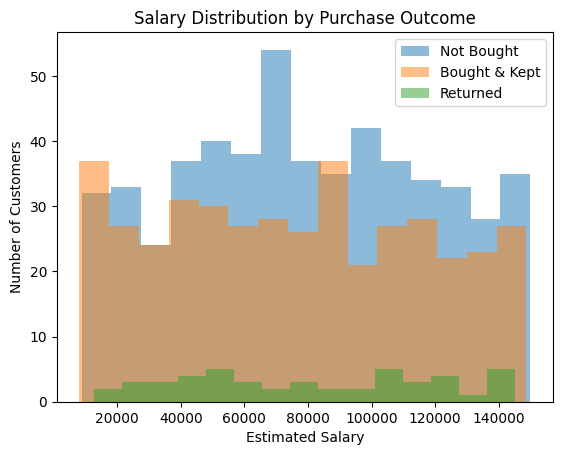

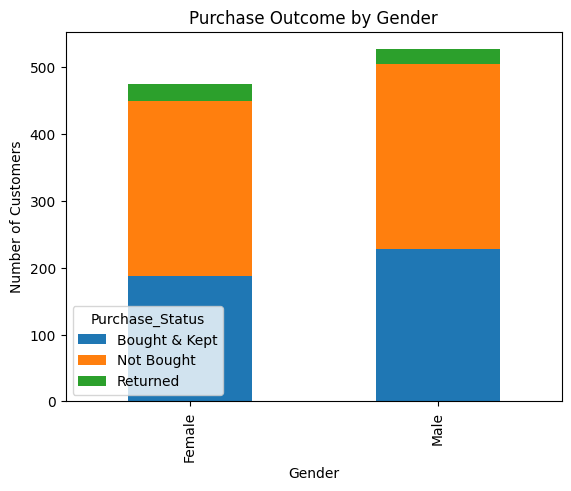

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Project_3.csv")

# Clean up
df = df.drop(columns=["User ID", "name"])

# Rename Purchased values for clarity
df["Purchase_Status"] = df["Purchased"].map({
    1: "Bought & Kept",
    0: "Not Bought",
    -1: "Returned"
})

# -----------------------------
# 1. Countplot of Purchase Status
# -----------------------------
df["Purchase_Status"].value_counts().plot(kind="bar", color=["green", "gray", "red"])
plt.title("Distribution of Purchase Outcomes")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

# -----------------------------
# 2. Age Distribution by Outcome
# -----------------------------
for status in df["Purchase_Status"].unique():
    subset = df[df["Purchase_Status"] == status]
    plt.hist(subset["Age"], bins=15, alpha=0.5, label=status)
plt.title("Age Distribution by Purchase Outcome")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

# -----------------------------
# 3. Salary Distribution by Outcome
# -----------------------------
for status in df["Purchase_Status"].unique():
    subset = df[df["Purchase_Status"] == status]
    plt.hist(subset["EstimatedSalary"], bins=15, alpha=0.5, label=status)
plt.title("Salary Distribution by Purchase Outcome")
plt.xlabel("Estimated Salary")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

# -----------------------------
# 4. Gender Breakdown by Outcome
# -----------------------------
gender_counts = pd.crosstab(df["Gender"], df["Purchase_Status"])
gender_counts.plot(kind="bar", stacked=True)
plt.title("Purchase Outcome by Gender")
plt.ylabel("Number of Customers")
plt.show()


# 4.Prepare the Data


Apply any data transformations and explain what and why


In [26]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Project_3.csv")  
df = df.drop(columns=['User ID', 'Name'], errors='ignore')

df['Purchased'] = df['Purchased'].replace(-1, 1)


# Binary encoding
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

scaler = StandardScaler()
df[['EstimatedSalary']] = scaler.fit_transform(df[['EstimatedSalary']])

bins = [19, 29, 39, 49, 59, 69]
labels = ['20s', '30s', '40s', '50s', '60s']
df['AgeBracket'] = pd.cut(df['Age'], bins=bins, labels=labels)
df = pd.get_dummies(df, columns=['AgeBracket'], drop_first=True)

print("Cleaned DataFrame head:")
print(df.head())
print("\nTarget distribution:")
print(df['Purchased'].value_counts())


Cleaned DataFrame head:
                  name  Gender  Age  EstimatedSalary  Purchased  \
0  Mr. Charles Carroll       1   59         0.321020          0   
1         Timothy Wood       0   37         0.348842          1   
2       Danny Whitaker       0   46         1.514106          1   
3       Franklin Villa       0   27         0.768185          0   
4        Carrie Miller       1   23         1.011449          1   

   AgeBracket_30s  AgeBracket_40s  AgeBracket_50s  AgeBracket_60s  
0           False           False            True           False  
1            True           False           False           False  
2           False            True           False           False  
3           False           False           False           False  
4           False           False           False           False  

Target distribution:
Purchased
0    539
1    462
Name: count, dtype: int64


# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


In [ ]:
def infrence(prams):
    results = m.run(prams)
    return results 